    ECM-1_setpoint_19C -> common O&M-1
    ECM-3_setpoint_19C_reschedule_8_8_8 -> common O&M-2
    ECM-2_reschedule_8_8_8 -> common O&M-3
    ECM-5_reschedule_8_8_8_default_infiltration -> common O&M-4

    E+ O&M-1 -> common O&M-1
    E+ O&M-2 -> common O&M-2
    E+ O&M-3 -> common O&M-3
    E+ O&M-5 -> common O&M-4

In [6]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 1. Paths
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")

eplus_ecm_path = (
    pred_dir / "ecm_savings_daily_EPlus_4P_FEBMAR_LoD1to3.csv"
)

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 2. Harmonisation maps
# ============================================================

quality_map = {
    # E+
    "beta": "LoD-1",
    "gamma": "LoD-2",
    "yearly": "LoD-3",
    "_beta": "LoD-1",
    "_gamma": "LoD-2",
    "bY": "LoD-3",

    # RC
    "default_occ": "LoD-1",
    "ONSITE_occ": "LoD-2",
    "bldg_LoD_Y": "LoD-3",
}

quality_label_map = {
    "LoD-1": r"LoD-1",
    "LoD-2": r"LoD-2",
    "LoD-3": r"LoD-3",
}

# E+ original ECM names -> common names used for RC comparison
# Based on your note:
# O&M-1 -> O&M-1 for RC
# O&M-2 -> O&M-2 for RC
# O&M-3 -> O&M-3 for RC
# O&M-5 -> O&M-4 for RC
eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",

    # Keep these, but they may not have direct RC equivalents.
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

# RC exported ECM names -> common names
rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",

    # This matches your note that E+ O&M-5 corresponds to RC O&M-4.
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",

    # Keep this separately because it is not clearly one of the four common ECMs.
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}

ecm_label_map = {
    "O&M-1": "O&M-1:\nSetpoint",
    "O&M-2": "O&M-2:\nSetpoint\n+ schedule",
    "O&M-3": "O&M-3:\nSchedule",
    "O&M-4": "O&M-4:\nSchedule\n+ window",
    "E+ only: O&M-4": "E+ only:\nO&M-4",
    "E+ only: O&M-6": "E+ only:\nO&M-6",
    "RC only: setpoint + default infiltration": "RC only:\nSetpoint\n+ window",
}

common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]


# ============================================================
# 3. Load E+ ECM savings
# ============================================================

def load_eplus_ecm_savings(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ ECM savings file: {path}")

    df = pd.read_csv(path)

    if "scenario" not in df.columns:
        raise ValueError("E+ file needs a 'scenario' column.")

    if "ecm" not in df.columns:
        raise ValueError("E+ file needs an 'ecm' column.")

    df["source"] = "EPlus"
    df["engine"] = "EnergyPlus"
    df["model_name"] = "EnergyPlus"

    df["data_quality"] = df["scenario"].map(quality_map)

    if "scenario_group" in df.columns:
        df["data_quality"] = df["data_quality"].fillna(
            df["scenario_group"].map(quality_map)
        )

    df["ecm_common"] = df["ecm"].map(eplus_ecm_to_common).fillna(df["ecm"])
    df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

    return df


# ============================================================
# 4. Load RC ECM savings
# ============================================================

def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"
    return "RC"


def infer_rc_scenario_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"
    return "unknown"


def load_rc_ecm_savings(base_date, rc_run_ids):
    dfs = []
    missing = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "ecm_savings_daily.csv"
        )

        if not path.exists():
            missing.append(path)
            continue

        df = pd.read_csv(path)

        scenario_group = infer_rc_scenario_group(run_label)
        model_name = infer_rc_model_name(run_label)

        df["source"] = "RC"
        df["engine"] = model_name
        df["model_name"] = model_name
        df["experiment_id"] = run_label
        df["scenario"] = scenario_group
        df["scenario_group"] = scenario_group
        df["data_quality"] = quality_map.get(scenario_group, "unknown")

        if "ecm" not in df.columns:
            raise ValueError(f"RC file has no 'ecm' column: {path}")

        df["ecm_common"] = df["ecm"].map(rc_ecm_to_common).fillna(df["ecm"])
        df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

        if "saving_frac" not in df.columns and "saving_rel" in df.columns:
            df["saving_frac"] = df["saving_rel"] / 100.0

        dfs.append(df)

    if missing:
        print("[WARN] Missing RC ECM files:")
        for p in missing:
            print("   ", p)

    if not dfs:
        raise ValueError("No RC ECM savings files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 5. Combine and save
# ============================================================

ecm_eplus = load_eplus_ecm_savings(eplus_ecm_path)

ecm_rc = load_rc_ecm_savings(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
)

ecm_savings_all = pd.concat(
    [ecm_eplus, ecm_rc],
    ignore_index=True,
)

# Keep only common comparable ECMs and LoD-1 to LoD-3
ecm_savings_common = ecm_savings_all[
    ecm_savings_all["ecm_common"].isin(common_ecm_order)
    & ecm_savings_all["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
].copy()

ecm_savings_common["ecm_label"] = pd.Categorical(
    ecm_savings_common["ecm_label"],
    categories=[ecm_label_map[x] for x in common_ecm_order],
    ordered=True,
)

ecm_savings_common["data_quality"] = pd.Categorical(
    ecm_savings_common["data_quality"],
    categories=["LoD-1", "LoD-2", "LoD-3"],
    ordered=True,
)

ecm_savings_common["engine"] = pd.Categorical(
    ecm_savings_common["engine"],
    categories=["EnergyPlus", "5R1C", "3R2C"],
    ordered=True,
)

display(
    ecm_savings_common.groupby(
        ["engine", "data_quality", "ecm_common"]
    )["sample_id"].nunique()
)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/938806982.py:248: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecm_savings_common.groupby(


engine      data_quality  ecm_common
EnergyPlus  LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
5R1C        LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                 

In [7]:
import pandas as pd
import numpy as np

engine_order = ["5R1C", "3R2C", "EnergyPlus"]
quality_order = ["LoD-1", "LoD-2", "LoD-3"]
ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

ecm_3d_df = (
    ecm_savings_common
    .groupby(["engine", "data_quality", "ecm_common"], observed=True)
    .agg(
        saving_abs_median=("saving_abs", "median"),
        saving_abs_q05=("saving_abs", lambda x: x.quantile(0.05)),
        saving_abs_q95=("saving_abs", lambda x: x.quantile(0.95)),
        saving_rel_median=("saving_rel", "median"),
        saving_rel_q05=("saving_rel", lambda x: x.quantile(0.05)),
        saving_rel_q95=("saving_rel", lambda x: x.quantile(0.95)),
        n_samples=("sample_id", "nunique"),
    )
    .reset_index()
)

ecm_3d_df["engine"] = pd.Categorical(
    ecm_3d_df["engine"],
    categories=engine_order,
    ordered=True,
)

ecm_3d_df["data_quality"] = pd.Categorical(
    ecm_3d_df["data_quality"],
    categories=quality_order,
    ordered=True,
)

ecm_3d_df["ecm_common"] = pd.Categorical(
    ecm_3d_df["ecm_common"],
    categories=ecm_order,
    ordered=True,
)

ecm_3d_df = ecm_3d_df.sort_values(
    ["ecm_common", "engine", "data_quality"]
)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

ecm_label_map = {
    "O&M-1": "O&M-1\nSetpoint",
    "O&M-2": "O&M-2\nSetpoint + schedule",
    "O&M-3": "O&M-3\nSchedule",
    "O&M-4": "O&M-4\nSetpoint + window",
}

def plot_ecm_3d_bars(
    summary_df,
    value_col="saving_abs_median",
    zlabel=r"Median absolute savings ($\mathrm{kWh\,m^{-2}}$)",
    engine_order=("5R1C", "3R2C", "EnergyPlus"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
    ecm_label_map=None,
    figsize=(14, 10),
):
    if ecm_label_map is None:
        ecm_label_map = {ecm: ecm for ecm in ecm_order}

    fig = plt.figure(figsize=figsize)

    vals_all = summary_df[value_col].dropna()
    norm = mcolors.Normalize(vmin=vals_all.min(), vmax=vals_all.max())
    cmap = cm.get_cmap("viridis")

    dx = 0.5
    dy = 0.5

    for i, ecm in enumerate(ecm_order, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")

        d = summary_df[summary_df["ecm_common"] == ecm].copy()

        for yi, engine in enumerate(engine_order):
            for xi, quality in enumerate(quality_order):
                sub = d[
                    (d["engine"] == engine)
                    & (d["data_quality"] == quality)
                ]

                if sub.empty:
                    dz = 0
                else:
                    dz = sub.iloc[0][value_col]

                color = cmap(norm(dz))

                ax.bar3d(
                    x=xi,
                    y=yi,
                    z=0,
                    dx=dx,
                    dy=dy,
                    dz=dz,
                    shade=True,
                    color=color,
                    alpha=0.9,
                )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        ax.set_xlabel("Data quality")
        ax.set_ylabel("Model complexity")
        ax.set_zlabel(zlabel)

        ax.set_xticks(np.arange(len(quality_order)) + dx / 2)
        ax.set_xticklabels(quality_order)

        ax.set_yticks(np.arange(len(engine_order)) + dy / 2)
        ax.set_yticklabels(engine_order)

    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cbar = fig.colorbar(
        mappable,
        ax=fig.axes,
        shrink=0.7,
        pad=0.08,
    )
    cbar.set_label(zlabel)

    plt.tight_layout()
    plt.show()

    return fig

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:131: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


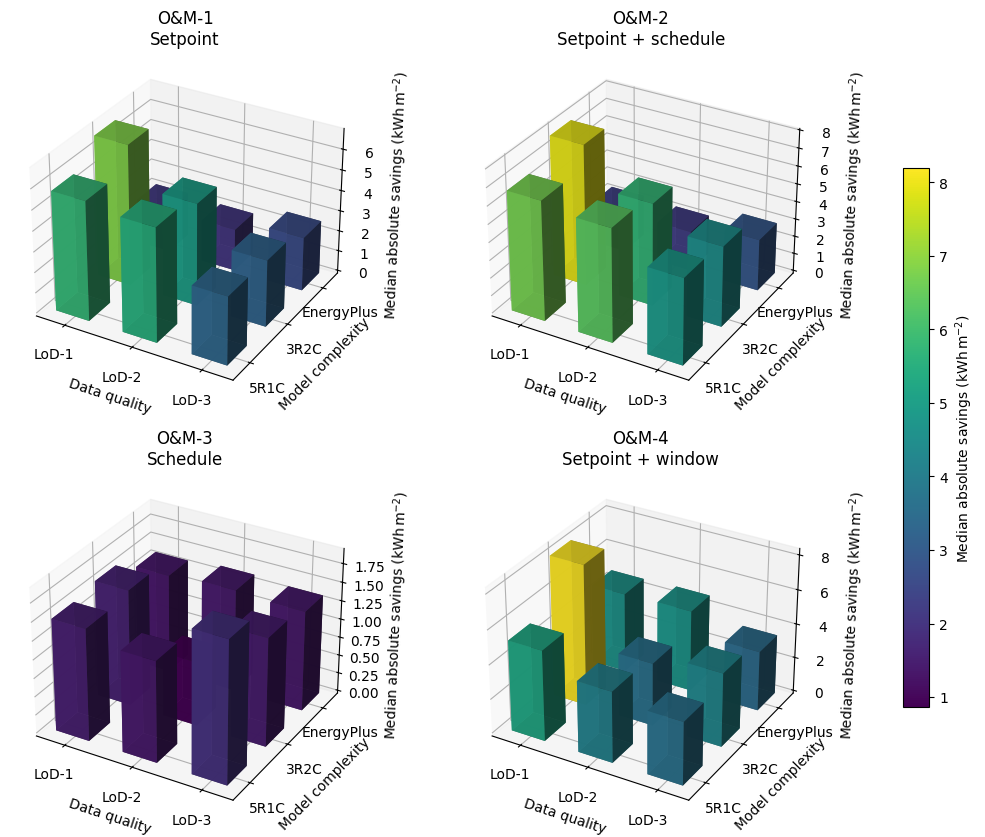

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/1568774138.py:131: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


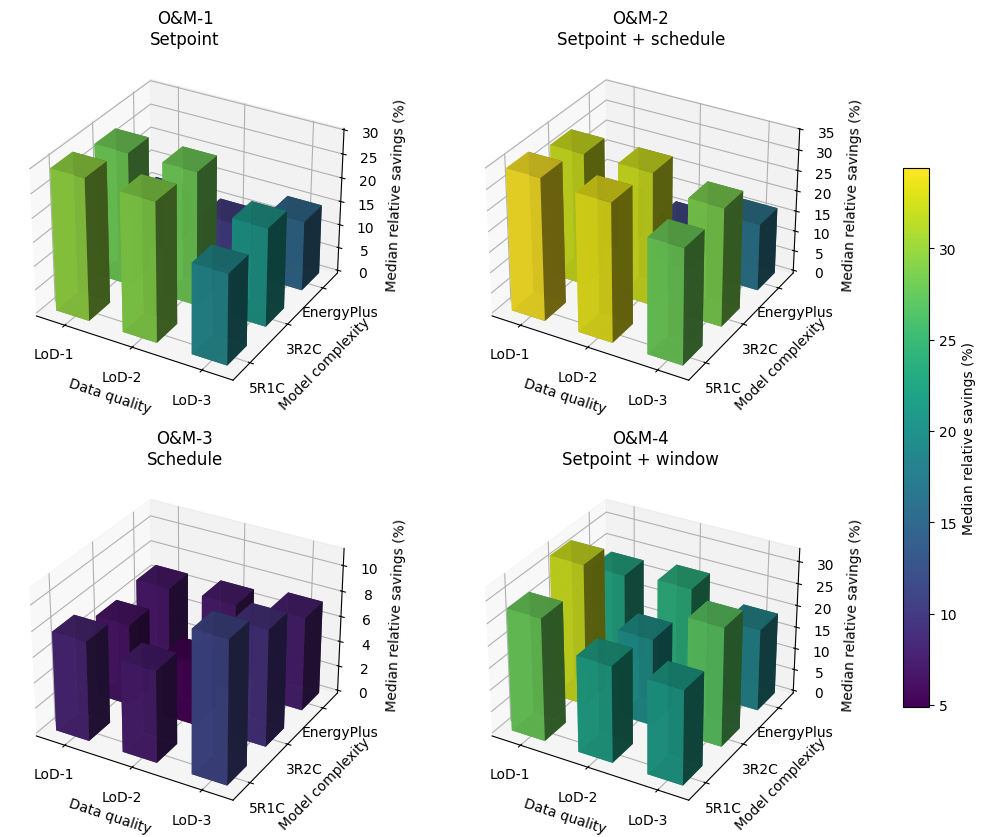

In [8]:
fig_abs_3d = plot_ecm_3d_bars(
    summary_df=ecm_3d_df,
    value_col="saving_abs_median",
    zlabel=r"Median absolute savings ($\mathrm{kWh\,m^{-2}}$)",
    ecm_label_map=ecm_label_map,
)
fig_rel_3d = plot_ecm_3d_bars(
    summary_df=ecm_3d_df,
    value_col="saving_rel_median",
    zlabel=r"Median relative savings (%)",
    ecm_label_map=ecm_label_map,
)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


engine_order = ["5R1C", "3R2C", "EnergyPlus"]
quality_order = ["LoD-1", "LoD-2", "LoD-3"]
ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

ecm_label_map = {
    "O&M-1": "O&M-1\nSetpoint",
    "O&M-2": "O&M-2\nSetpoint + schedule",
    "O&M-3": "O&M-3\nSchedule",
    "O&M-4": "O&M-4\nSetpoint + window",
}


def build_surface_matrix(df, ecm, value_col, engine_order, quality_order):
    d = df[df["ecm_common"] == ecm].copy()

    table = (
        d.pivot_table(
            index="engine",
            columns="data_quality",
            values=value_col,
            aggfunc="first",
        )
        .reindex(index=engine_order, columns=quality_order)
    )

    return table.to_numpy(dtype=float)


def plot_ecm_three_surfaces(
    summary_df,
    median_col="saving_abs_median",
    q05_col="saving_abs_q05",
    q95_col="saving_abs_q95",
    zlabel=r"Heating energy savings ($\mathrm{kWh\,m^{-2}}$)",
    engine_order=("5R1C", "3R2C", "EnergyPlus"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
    ecm_label_map=None,
    figsize=(14, 10),
):
    if ecm_label_map is None:
        ecm_label_map = {e: e for e in ecm_order}

    x = np.arange(len(quality_order))
    y = np.arange(len(engine_order))
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=figsize)

    for i, ecm in enumerate(ecm_order, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")

        Z50 = build_surface_matrix(
            summary_df, ecm, median_col, engine_order, quality_order
        )
        Z05 = build_surface_matrix(
            summary_df, ecm, q05_col, engine_order, quality_order
        )
        Z95 = build_surface_matrix(
            summary_df, ecm, q95_col, engine_order, quality_order
        )

        # q05 surface
        ax.plot_surface(
            X, Y, Z05,
            alpha=0.25,
            linewidth=0,
            antialiased=True,
        )

        # median surface
        ax.plot_surface(
            X, Y, Z50,
            alpha=0.75,
            linewidth=0,
            antialiased=True,
        )

        # q95 surface
        ax.plot_surface(
            X, Y, Z95,
            alpha=0.25,
            linewidth=0,
            antialiased=True,
        )

        # also show the median points
        ax.scatter(
            X.flatten(),
            Y.flatten(),
            Z50.flatten(),
            s=30,
            color="black",
            zorder=10,
        )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        ax.set_xlabel("Data quality")
        ax.set_ylabel("Model complexity")
        ax.set_zlabel(zlabel)

        ax.set_xticks(x)
        ax.set_xticklabels(list(quality_order))

        ax.set_yticks(y)
        ax.set_yticklabels(list(engine_order))

    legend_handles = [
        Patch(alpha=0.25, label=r"$q_{05}$"),
        Patch(alpha=0.75, label=r"$q_{50}$"),
        Patch(alpha=0.25, label=r"$q_{95}$"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.98),
    )

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

    return fig

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/4245863517.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d.pivot_table(
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/4245863517.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d.pivot_table(
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/4245863517.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d.pivot_table(
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_89640/4245863517.

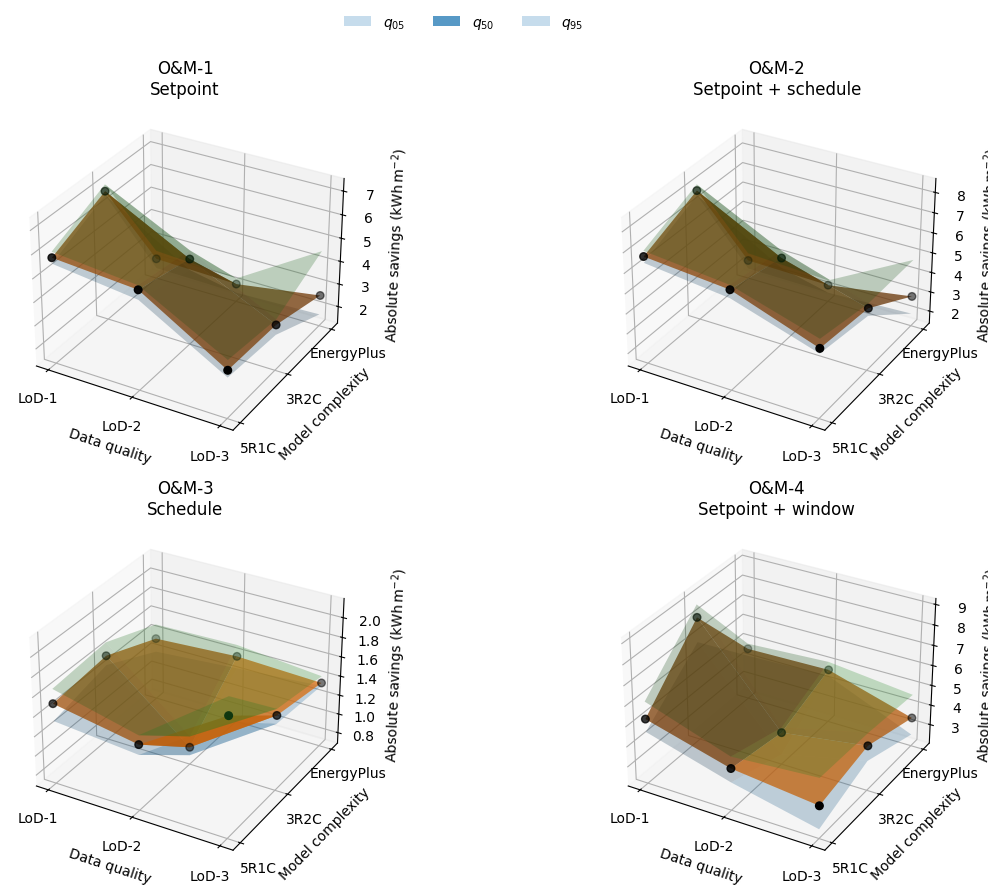

In [10]:
fig_abs_surface = plot_ecm_three_surfaces(
    summary_df=ecm_3d_df,
    median_col="saving_abs_median",
    q05_col="saving_abs_q05",
    q95_col="saving_abs_q95",
    zlabel=r"Absolute savings ($\mathrm{kWh\,m^{-2}}$)",
    ecm_label_map=ecm_label_map,
)